In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
from resources.lattices import geometry, effProperties, rDthickness, get_nodes, connectivity, plot_lattice

In [2]:
def get_n0s(nodes, realElem):
    n0s = []
    for elem in realElem:
        n0 = nodes[elem[2]] - nodes[elem[1]]
        n0s.append(n0)
    n0s = np.array(n0s)
    return n0s

def edgeElems(nodes, elems, geom):
    t_old = geom[12]
    t_new = np.array([t_old] * len(elems))
    min_x, max_x = min(nodes[:,0]), max(nodes[:,0])
    min_y, max_y = min(nodes[:,1]), max(nodes[:,1])
    for i, elem in enumerate(elems):
        node1 = nodes[elem[1]]
        node2 = nodes[elem[2]]
        if (node1[0] == max_x and node2[0] == max_x) or (node1[0] == min_x and node2[0] == min_x):
            t_new[i] = t_old/2
        elif (node1[1] == max_y and node2[1] == max_y) or (node1[1] == min_y and node2[1] == min_y):
            t_new[i] = t_old/2
    geom[12] = t_new
    return geom

In [3]:
def get_ns(n0s):
    ns = []
    for n0 in n0s:
        ns.append(n_values(n0))
    return np.array(ns)
    
def n_values(n0):
    return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])

def get_Nmatrix(ns):
    N = []
    for i in range(len(ns)):
        N.append([ns[i][0]*ns[i][0], ns[i][1]*ns[i][1], ns[i][0]*ns[i][1]])
    return np.array(N)

def calc_c(n0, geom, mode, i):
    if mode.lower() == "unit":
        return (geom[12][i]*(np.sqrt(n0[0]**2 + n0[1]**2))) / (geom[10])
    elif mode.lower() == "lattice":
        return (geom[12][i]*(np.sqrt(n0[0]**2 + n0[1]**2))) / (geom[10])

In [4]:
def calc_Kmatrix(LAT, l, nnx, mode, dis='per', count=0, plot=False):
    rD = 0.2
    E_s = 123e9
    v_s = 0.3

    geom = geometry(LAT, l, nnx, stiffCalc=True, mode=mode)
    
    nodes, Dnodes = get_nodes(LAT, geom, dis, mode=mode, stiff=True)
    elems = connectivity(LAT, nodes, stiff=True, geom=geom, mode=mode)
    geomK = edgeElems(nodes, elems, geom)

    if plot:
        plot_lattice(elems, nodes, geomK)

    n0s = get_n0s(nodes, elems)
    ns = get_ns(n0s)
    Nmatrix = get_Nmatrix(ns)

    c0matrix = np.zeros((len(ns),len(ns)))
    for i in range(len(ns)):
        c0matrix[i][i] = calc_c(n0s[i], geomK, mode, i)
    #print(np.sum(c0matrix))
    Kmatrix = E_s*np.matmul(np.matmul(Nmatrix.T, c0matrix), Nmatrix).round(10)
    
    Ks = []
    Ks.append(Kmatrix)
    
    for jj in range(1, count+1):
        nodes, Dnodes = get_nodes(LAT, geom, dis, mode=mode, stiff=True, sim=jj)
        if dis.lower() == 'dn':                                   # import struts thicks from struts.csv file
            nodes = Dnodes
        
        if plot:
            plot_lattice(elems, nodes, geomK)
            
        n0s = get_n0s(nodes, elems)
        ns = get_ns(n0s)
        Nmatrix = get_Nmatrix(ns)

        c0matrix = np.zeros((len(ns),len(ns)))
        for i in range(len(ns)):
            c0matrix[i][i] = calc_c(n0s[i], geomK, mode, i)
        #print(np.sum(c0matrix))
        Kmatrix = E_s*np.matmul(np.matmul(Nmatrix.T, c0matrix), Nmatrix).round(10)
        Ks.append(Kmatrix)

    return np.array(Ks)

In [22]:
LAT = "tri"
l = 0.01
nnx = 10
dis = 'dn'      # None, dn, ds

mode = "lattice"
Ks = calc_Kmatrix(LAT, l, nnx, mode, dis=dis, count=10, plot=False)

mode = "unit"
Kmatrix_unit = calc_Kmatrix(LAT, l, nnx, mode, plot=False)

C:\Users\exy053\AppData\Local\Temp/ipykernel_9636/4011440371.py:8: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


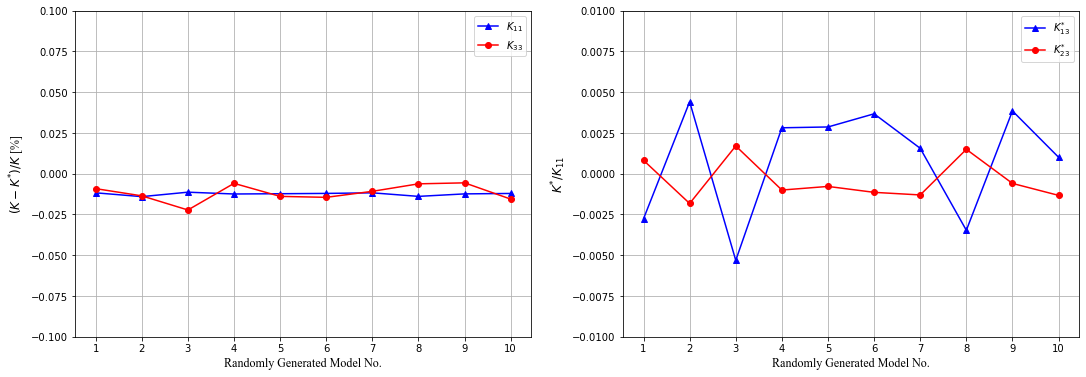

In [23]:
def plot_variation(Ks):
    K11, K33, K13, K23 = [], [], [], []
    for K in Ks[1:]:
        K11.append((Ks[0][0][0]-K[0][0])/Ks[0][0][0])
        K33.append((Ks[0][2][2]-K[2][2])/Ks[0][2][2])
        K13.append(K[0][2]/Ks[0][0][0])
        K23.append(K[1][2]/Ks[0][0][0])


    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_figheight(6)
    fig.set_figwidth(18)

    ax1.set_ylabel('$(K-K^{*})/K$ [%]', fontsize=12, fontname="Times New Roman")
    ax1.set_xlabel('Randomly Generated Model No.', fontsize=12, fontname="Times New Roman")

    ax1.set_ylim([-0.1, 0.1])
    ax1.set_xticks([i+1 for i in range(len(K11))])

    ax1.plot([i+1 for i in range(len(K11))], K11, 'b^-', label='$K_{11}$')
    ax1.plot([i+1 for i in range(len(K33))], K33, 'ro-', label='$K_{33}$')

    ax1.grid()
    ax1.legend()

    ax2.set_ylabel('$K^{*}/K_{11}$', fontsize=12, fontname="Times New Roman")
    ax2.set_xlabel('Randomly Generated Model No.', fontsize=12, fontname="Times New Roman")

    ax2.set_ylim([-0.01, 0.01])
    ax2.set_xticks([i+1 for i in range(len(K11))])

    ax2.plot([i+1 for i in range(len(K13))], K13, 'b^-', label='$K^{*}_{13}$')
    ax2.plot([i+1 for i in range(len(K23))], K23, 'ro-', label='$K^{*}_{23}$')

    ax2.grid()
    ax2.legend()
    
plot_variation(Ks)

In [26]:
def check_isotropy(K):
    if round(K[0][0]/K[0][1], 3) == 3.0 and round(K[0][0]/K[1][1], 3) == 1.0 and round(K[0][1]/K[2][2], 3) == 1.0:
        return True
    else:
        return False

def calc_effectiveProperties(K):
    iso = check_isotropy(K)
    v = 1/(K[0][0]/K[0][1]+1)
    E = (K[0][0]*((1+v)*(1-2*v)))/(1-v)
    return E, v, iso

E_eff, v_eff, iso = calc_effectiveProperties(Ks[0])
E_eff, v_eff, iso

(7687499698.649999, 0.2500000060000001, True)

In [27]:
v_iso = 0.25
K_iso_pStress = (1/(1-v_iso**2))*np.array([[1, v_iso, 0],
                                           [v_iso, 1, 0],
                                           [0, 0, (1-v_iso)/2]])
K_iso_pStrain = (1/((1-2*v_iso)*(1+v_iso)))*np.array([[1-v_iso, v_iso, 0],
                                                       [v_iso, 1-v_iso, 0],
                                                       [0, 0, (1-2*v_iso)/2]])

K_iso_pStress/min(K_iso_pStress[0][:2]), K_iso_pStrain/min(K_iso_pStrain[0][:2])

(array([[4. , 1. , 0. ],
        [1. , 4. , 0. ],
        [0. , 0. , 1.5]]),
 array([[3., 1., 0.],
        [1., 3., 0.],
        [0., 0., 1.]]))